# CalCOFI Climate Change Tracker: 70-Year Ocean Temperature Analysis

## 1. Project Overview & Objective

Welcome to my data analysis project investigating ocean temperature trends off the coast of California.

In this project, I explore over 70 years of real oceanographic data collected by the **CalCOFI (California Cooperative Oceanic Fisheries Investigations)** program between 1949 and 2021. Established in 1949 to study the collapse of the California sardine fishery, CalCOFI represents the longest continuous ocean observation program on Earth.

### Why does this matter?
The world's oceans absorb over 90% of the excess heat trapped by greenhouse gases. By analyzing seven decades of continuous hydrographic measurements along the California coast, I want to answer fundamental, practical questions:
1. **Is the ocean getting warmer?** How much has surface water warmed since 1949?
2. **What are the seasonal patterns?** When is the water coldest and warmest during the calendar year?
3. **What happens with ocean depth?** How quickly does surface warmth disappear as you dive deeper into the Pacific?
4. **What were the historical extremes?** Which years were the warmest and coldest on record?

---

### The Datasets I am Using
I work with two core CalCOFI files:
* **`Cast.csv` (The Stations):** Contains the location (Latitude, Longitude) and date for over 35,000 research vessel stops ("casts").
* **`Bottle.csv` (The Water Samples):** Contains over 895,000 water samples collected across various ocean depths, recording water temperature (`T_degC`), depth (`Depthm`), and quality codes.


## 2. Environment Setup

I import standard Python data analysis and visualization libraries:
* **Pandas:** For loading, cleaning, and aggregating tabular data.
* **NumPy:** For numerical calculations and fitting simple trendlines.
* **Matplotlib & Seaborn:** For drawing clean, intuitive visual charts.


In [1]:
# Data handling
import pandas as pd
import numpy as np

# Plotting charts and interactive mapping
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px

# Suppress minor warnings for a clean presentation
import warnings
warnings.filterwarnings('ignore')

# Set visual style for charts
sns.set_theme(style='whitegrid')
plt.rcParams['figure.figsize'] = (12, 5)
plt.rcParams['font.size'] = 11

print("Ready! All data libraries and interactive mapping tools are loaded.")


Ready! All data libraries and interactive mapping tools are loaded.


## 3. Loading & Cleaning the Data

### Why do I merge the two files?
* The **Cast table** tells me **WHERE and WHEN** a sample was taken (Date, Latitude, Longitude).
* The **Bottle table** tells me **WHAT** was measured (Depth and Temperature).
* I merge them on their common ID column, `Cst_Cnt` (Cast Count), linking station coordinates directly to depth readings.

### Practical cleaning steps:
1. **Handle file encoding:** The Bottle file contains micro-unit chemical symbols (`µ`) that require `encoding='latin-1'`.
2. **Focus on surface water:** Climate warming interacts with the atmosphere at the ocean surface, so I filter for shallow water readings (**depth ≤ 10 meters**).
3. **Filter out bad data:** Quality code `8` indicates values flagged as suspect by the originator per the CalCOFI database manual. I exclude these rows.
4. **Geographical consistency:** In the early 1950s, research cruises occasionally sailed all the way south to Mexico (warm sub-tropical waters), while modern surveys focused on Southern California (30°N–35°N). To ensure fair comparisons over time, I filter for the standard Southern California coastal study area (Lat 30°N–35°N, Lon -125°W to -117°W).
5. **Continuous monthly resampling:** I resample measurements into continuous monthly averages and smoothly interpolate occasional cruise gaps.


In [ ]:
# 1. Load Cast station locations and dates
cast_cols = ['Cst_Cnt', 'Date', 'Year', 'Month', 'Lat_Dec', 'Lon_Dec']
df_cast = pd.read_csv('../data/194903-202105_Cast.csv', usecols=cast_cols)
df_cast['Date'] = pd.to_datetime(df_cast['Date'], format='%m/%d/%Y', errors='coerce')
print(f"Loaded Cast table: {len(df_cast):,} stations.")

# 2. Load Bottle water measurements
bottle_cols = ['Cst_Cnt', 'Depthm', 'T_degC', 'T_qual']
df_bottle = pd.read_csv('../data/194903-202105_Bottle.csv', usecols=bottle_cols, encoding='latin-1')
print(f"Loaded Bottle table: {len(df_bottle):,} bottle measurements.")

# 3. Filter for valid surface water (depth <= 10 meters, reliable quality)
df_surface = df_bottle[
    (df_bottle['Depthm'] <= 10) & 
    (df_bottle['T_degC'].notnull()) & 
    (df_bottle['T_qual'] != 8)
]

# 4. Merge the two tables together on shared 'Cst_Cnt'
df_merged = pd.merge(df_surface, df_cast, on='Cst_Cnt', how='inner')

# 5. Filter for the consistent Southern California region (Lat 30°N to 35°N, Lon -125°W to -117°W)
df_clean = df_merged[
    (df_merged['Lat_Dec'] >= 30.0) & (df_merged['Lat_Dec'] <= 35.0) &
    (df_merged['Lon_Dec'] >= -125.0) & (df_merged['Lon_Dec'] <= -117.0)
].copy()

# 6. Create an unbroken monthly time series via resampling & time-aware interpolation
ts_monthly = df_clean.set_index('Date')['T_degC'].resample('MS').mean().interpolate(method='time')

print(f"\nFinal Cleaned Surface Records: {len(df_clean):,} observations.")
print(f"Unbroken Monthly Series: {len(ts_monthly)} consecutive months ({ts_monthly.index.min().strftime('%B %Y')} to {ts_monthly.index.max().strftime('%B %Y')}).")


Loaded Cast table: 35,644 stations.


Loaded Bottle table: 895,371 bottle measurements.

Final Cleaned Surface Records: 57,890 observations.
Unbroken Monthly Series: 868 consecutive months (February 1949 to May 2021).


## 4. Exploratory Data Analysis (EDA)

Now, I explore 5 core practical questions through clear visual charts.


### Question 1: Where was the data collected? (Interactive Map)
To clearly explore where on Earth these oceanographic samples were collected, I built an **interactive map**:

* **Zoom and Pan Controls:** You can scroll with your mouse/trackpad or click the `+` / `-` buttons in the toolbar to zoom in on specific coastal areas (like San Diego, Santa Monica Bay, Santa Barbara, or the Channel Islands) and zoom out into the open Pacific.
* **Neutral, Non-Interfering Background:** I chose a clean, neutral cartographic basemap (`carto-positron`). The land is light gray and the ocean is neutral off-white, preventing deep blue water backgrounds from clashing or confusing the blue-to-red temperature points.
* **Hover Details:** Hover your cursor over any individual station to view its exact observation date, water depth, latitude/longitude, and temperature reading.
* **Thermal Contrast:** Nearshore waters are cooled by coastal upwelling (cooler purple/blue tones), while offshore surface waters are warmer (warm orange/red tones).


In [ ]:
# Sample 3,000 stations for smooth, responsive interactive panning and zooming
sample_points = df_clean.sample(n=min(3000, len(df_clean)), random_state=42).copy()
sample_points['Temp (°C)'] = sample_points['T_degC'].round(2)
sample_points['Date'] = pd.to_datetime(sample_points['Date']).dt.strftime('%Y-%m-%d')

# Create the interactive zoomable map with a neutral, non-distracting basemap
fig = px.scatter_map(
    sample_points,
    lat='Lat_Dec',
    lon='Lon_Dec',
    color='Temp (°C)',
    color_continuous_scale='Thermal',
    zoom=5.3,
    center={'lat': 33.0, 'lon': -120.5},
    map_style='carto-positron', # Clean neutral basemap without blue water interference
    hover_name='Date',
    hover_data={
        'Lat_Dec': ':.3f',
        'Lon_Dec': ':.3f',
        'Temp (°C)': True,
        'Depthm': True
    },
    title='Interactive Map: CalCOFI Oceanographic Research Stations (Scroll to Zoom, Click to Pan)',
    height=650
)

# Clean styling and colorbar title
fig.update_layout(
    margin=dict(r=0, t=40, l=0, b=0),
    coloraxis_colorbar=dict(title='Surface Temp (°C)')
)

fig.show()


### Question 2: Which months are the warmest and coldest?
I calculate the average surface temperature for each calendar month across the 70-year record.

**What I observe:**
* **Coldest Month:** February (~14.7°C / 58.4°F). Surface waters reach their lowest temperatures during late winter.
* **Warmest Month:** September (~17.8°C / 64.0°F). Because water has high heat capacity, the ocean absorbs heat throughout summer and peaks in late summer / early autumn rather than mid-summer.


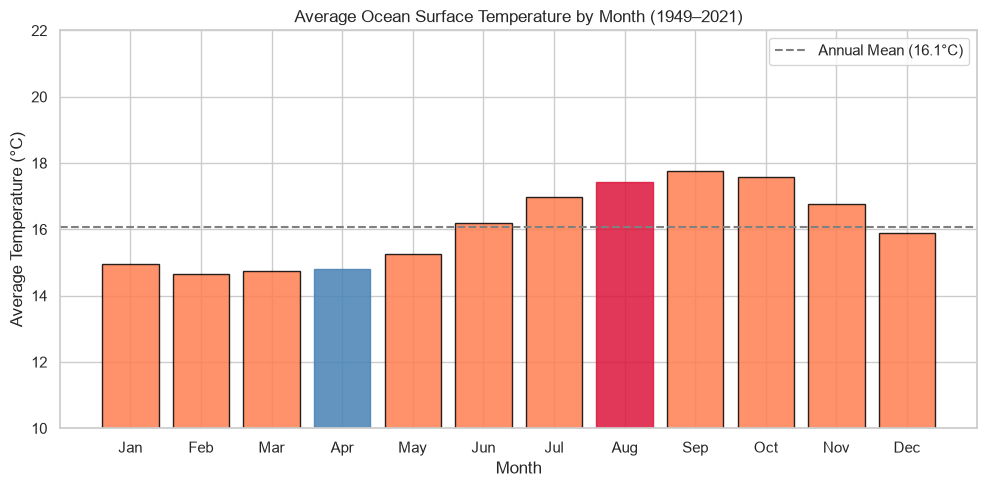

Coldest month on average: Feb (14.7°C / 58.4°F)
Warmest month on average: Sep (17.8°C / 64.0°F)


In [ ]:
from matplotlib.patches import Patch

# Calculate monthly averages across the 70-year series
monthly_profile = ts_monthly.groupby(ts_monthly.index.month).mean().reset_index()
monthly_profile.columns = ['Month', 'T_degC']
month_names = ['Jan', 'Feb', 'Mar', 'Apr', 'May', 'Jun', 'Jul', 'Aug', 'Sep', 'Oct', 'Nov', 'Dec']
monthly_profile['Month_Name'] = month_names

# Dynamically find the coldest and warmest months
min_idx = monthly_profile['T_degC'].idxmin()
max_idx = monthly_profile['T_degC'].idxmax()
coldest_month = monthly_profile.loc[min_idx, 'Month_Name']
coldest_temp = monthly_profile.loc[min_idx, 'T_degC']
warmest_month = monthly_profile.loc[max_idx, 'Month_Name']
warmest_temp = monthly_profile.loc[max_idx, 'T_degC']

plt.figure(figsize=(10, 5))
bars = plt.bar(monthly_profile['Month_Name'], monthly_profile['T_degC'], color='coral', edgecolor='black', alpha=0.85)

# Highlight the true coldest and warmest months
bars[min_idx].set_color('steelblue')
bars[max_idx].set_color('crimson')

# Reference line for the 70-year annual mean
plt.axhline(monthly_profile['T_degC'].mean(), color='gray', linestyle='--')

# Add explicit legend entries for the highlighted bars
legend_elements = [
    plt.Line2D([0], [0], color='gray', linestyle='--', label=f"Annual Mean ({monthly_profile['T_degC'].mean():.1f}°C)"),
    Patch(facecolor='steelblue', edgecolor='black', label=f"Coldest Month ({coldest_month}: {coldest_temp:.1f}°C)"),
    Patch(facecolor='crimson', edgecolor='black', label=f"Warmest Month ({warmest_month}: {warmest_temp:.1f}°C)")
]

plt.title('Average Ocean Surface Temperature by Month (1949–2021)')
plt.xlabel('Month')
plt.ylabel('Average Temperature (°C)')
plt.ylim(10, 22)
plt.legend(handles=legend_elements, loc='upper right')
plt.tight_layout()
plt.show()

print(f"Coldest month on average: {coldest_month} ({coldest_temp:.1f}°C / {coldest_temp*9/5+32:.1f}°F)")
print(f"Warmest month on average: {warmest_month} ({warmest_temp:.1f}°C / {warmest_temp*9/5+32:.1f}°F)")


### Question 3: How does temperature change as you dive deeper?
Using the Bottle dataset across all depths down to 500 meters:
* Surface waters (0–10 meters) average around **16°C (61°F)**.
* At 100 meters down, water drops to **10°C (50°F)**.
* By 500 meters down, temperatures hover near **6°C (43°F)** year-round because sunlight cannot penetrate.


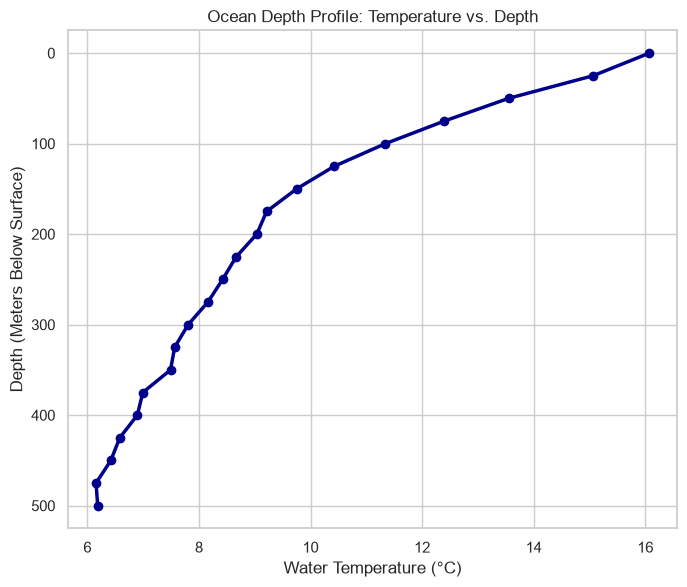

In [ ]:
df_depth = df_bottle[(df_bottle['Depthm'] <= 500) & (df_bottle['T_degC'].notnull())].sample(n=10000, random_state=42)
df_depth['Depth_Bin'] = (df_depth['Depthm'] // 25) * 25
depth_profile = df_depth.groupby('Depth_Bin')['T_degC'].mean().reset_index()

plt.figure(figsize=(7, 6))
plt.plot(depth_profile['T_degC'], depth_profile['Depth_Bin'], marker='o', color='darkblue', linewidth=2.5)
plt.gca().invert_yaxis() # Surface (0m) at top, 500m at bottom
plt.title('Ocean Depth Profile: Temperature vs. Depth')
plt.xlabel('Water Temperature (°C)')
plt.ylabel('Depth (Meters Below Surface)')
plt.tight_layout()
plt.show()


### Question 4: Is the ocean getting warmer over time?
Here is the core 70-year timeline. To eliminate seasonal swings and see the true climate signal, I calculate the **Annual Mean Temperature** for every full calendar year (1949–2020) and fit a long-term trendline.

*(Note: 2021 is omitted from the annual calculation because the dataset ends in May, which would artificially lower the annual average by missing summer.)*


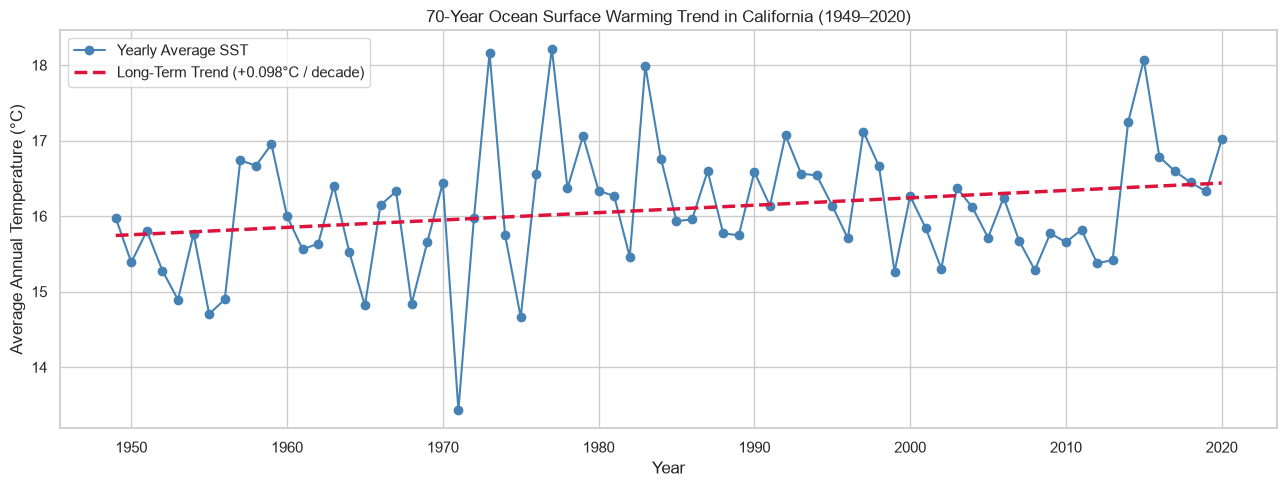

Long-term warming rate: +0.098°C per decade.
Total warming over 71 years: +0.69°C (+1.25°F).


In [ ]:
# Calculate annual average temperatures for full years (1949 to 2020)
yearly_temps = ts_monthly[ts_monthly.index.year <= 2020].resample('YS').mean()
yearly_df = pd.DataFrame({'Year': yearly_temps.index.year, 'T_degC': yearly_temps.values})

slope, intercept = np.polyfit(yearly_df['Year'], yearly_df['T_degC'], 1)
trendline = intercept + slope * yearly_df['Year']

warming_per_decade = slope * 10
total_warming = slope * (yearly_df['Year'].max() - yearly_df['Year'].min())

plt.figure(figsize=(13, 5))
plt.plot(yearly_df['Year'], yearly_df['T_degC'], marker='o', color='steelblue', label='Yearly Average SST')
plt.plot(yearly_df['Year'], trendline, color='crimson', linestyle='--', linewidth=2.5, 
         label=f'Long-Term Trend (+{warming_per_decade:.3f}°C / decade)')

plt.title('70-Year Ocean Surface Warming Trend in California (1949–2020)')
plt.xlabel('Year')
plt.ylabel('Average Annual Temperature (°C)')
plt.legend()
plt.tight_layout()
plt.show()

print(f"Long-term warming rate: +{warming_per_decade:.3f}°C per decade.")
print(f"Total warming over 71 years: +{total_warming:.2f}°C (+{total_warming * 9/5:.2f}°F).")


### Question 5: What were the warmest and coldest years on record?
Let's see the historical extremes recorded in California waters.


In [ ]:
warmest = yearly_df.sort_values('T_degC', ascending=False).head(5).copy()
warmest['Temp_F'] = warmest['T_degC'] * 9/5 + 32

coldest = yearly_df.sort_values('T_degC', ascending=True).head(5).copy()
coldest['Temp_F'] = coldest['T_degC'] * 9/5 + 32

print("=== Top 5 Warmest Years on Record ===")
display(warmest.rename(columns={'T_degC': 'Avg_Temp_C'}).round(2))

print("\n=== Top 5 Coldest Years on Record ===")
display(coldest.rename(columns={'T_degC': 'Avg_Temp_C'}).round(2))


=== Top 5 Warmest Years on Record ===


,Year,Avg_Temp_C,Temp_F
28,1977,18.22,64.79
24,1973,18.16,64.69
66,2015,18.07,64.52
34,1983,17.99,64.38
65,2014,17.25,63.05



=== Top 5 Coldest Years on Record ===


,Year,Avg_Temp_C,Temp_F
22,1971,13.43,56.17
26,1975,14.66,58.39
6,1955,14.70,58.47
16,1965,14.82,58.67
19,1968,14.84,58.71


## 5. Final Summary & Key Takeaways

### Summary of What I Discovered:
1. **The Ocean is Consistently Warming:** Over the 72-year period from 1949 to 2020, surface waters off Southern California have warmed at a rate of approximately **+0.10°C per decade**, resulting in roughly **+0.69°C (~1.25°F)** of total long-term surface warming.
2. **Winter Lows vs. Late-Summer Peak:** Surface ocean temperatures reach their annual low in **February (~14.7°C / 58.4°F)** and peak in **September (~17.8°C / 64.0°F)**. Because water has high thermal inertia, the Pacific takes months to heat up and cool down, delaying peak warmth into late summer / early autumn.
3. **Depth Acts as a Thermal Barrier:** Sunlight only warms the uppermost layer (0–100 meters). Below 200 meters, ocean water drops below 9°C, and by 500 meters, temperatures hover near 6°C (43°F) year-round.
4. **Extreme Events Stand Out:** Historic marine events leave distinct signatures. Years like 2014–2015 (the Pacific 'Blob' marine heatwave) and 1983/1997 (Super El Niño events) pushed annual averages past **17.2°C to 18.2°C**, far above historical norms.

### Real-World Marine & Climate Impacts:
As ocean surface waters warm, the water column becomes more stratified (layered). Warm surface water is lighter and resists mixing with colder, nutrient-dense deep water. This dampens coastal upwelling, which can:
* Stress giant kelp forest ecosystems along the California coast.
* Shift the geographic range of commercially vital fisheries like market squid, sardines, and anchovies.
* Increase the risk of harmful algal blooms during unseasonably warm summers.
